# **Logistic Regression from Scratch**

### This notebook demonstrates logistic regression using multiple approaches:
- ### Using `sklearn`
- ### Perceptron trick with step function
- ### Perceptron trick with sigmoid
- ### Logistic regression using sigmoid and gradient descent

## 📊 Section 1: Dataset Generation

#### Creating a simple synthetic dataset for binary classification using `make_classification`.

In [1]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples= 100, n_features= 2, n_informative= 1, n_redundant= 0,
                          n_classes= 2, n_clusters_per_class=1, random_state= 41, hypercube= False, class_sep=30)

## 🖼️ Section 2: Visualizing the Data

#### Plotting the data points to understand the distribution.

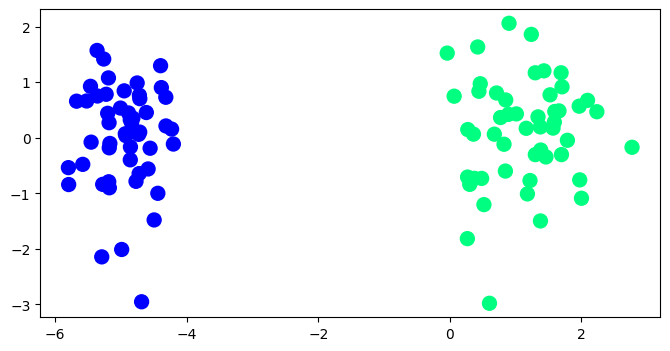

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize = (8,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap= 'winter', s=100)

## 🤖 Section 3: Logistic Regression using Sklearn

#### Fitting a simple logistic regression model using `sklearn` as a baseline.

In [3]:
from sklearn.linear_model import LogisticRegression

In [4]:
lor = LogisticRegression()

In [5]:
lor.fit(X, y)

LogisticRegression()

In [6]:
lor.coef_

array([[1.77255101, 0.01190507]])

In [7]:
lor.intercept_

array([3.54700273])

In [8]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [9]:
m

np.float64(-148.89041745447042)

In [10]:
b

array([-297.9404898])

In [11]:
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

(-3.0, 2.0)

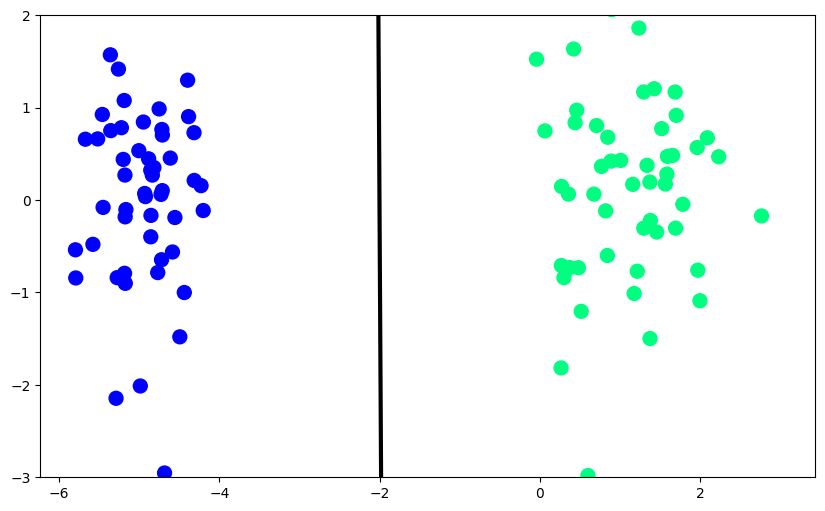

In [12]:
plt.figure(figsize = (10,6))
plt.plot(x_input, y_input, color='black', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap= 'winter', s=100)
plt.ylim(-3,2)

## 🧠 Section 4: Perceptron using Step Function

#### Implementing perceptron learning with a step activation.

In [13]:
def perceptron(X,y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.7
    
    for i in range(70000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) *X[j]
    return weights[0], weights[1:]

In [14]:
def step(z):
    return 1 if z > 0 else 0

In [15]:
intercept_ , coef_ = perceptron(X,y)

In [16]:
# coef_
m1 = -(coef_[0]/coef_[1])
b1 = -(intercept_/coef_[1])

In [17]:
m1

np.float64(4.367359088972508)

In [18]:
b1

np.float64(6.258108472909304)

In [19]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m1 * x_input1 + b1

(-3.0, 2.0)

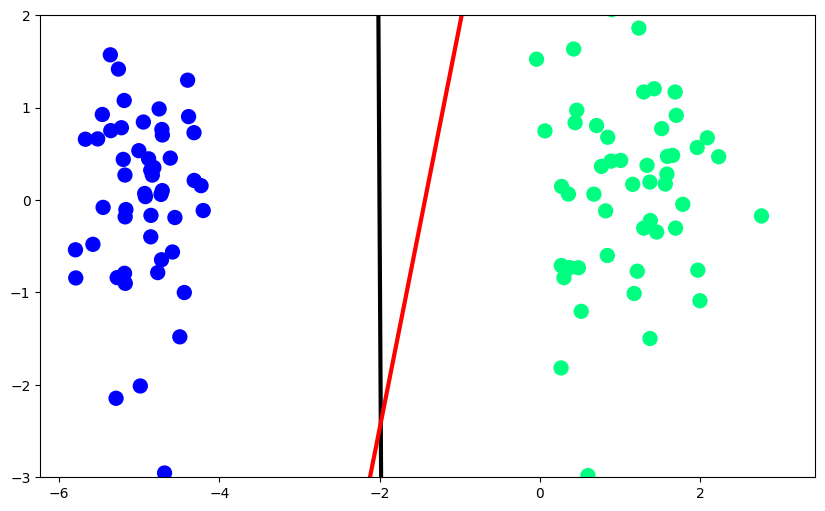

In [20]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='black', linewidth=3)
plt.plot(x_input1,y_input1,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

## 📈 Section 5: Perceptron using Sigmoid Function

#### Implementing perceptron learning with a sigmoid activation.

In [21]:
def Perceptron_sigmoid(X, y):
    X = np.insert(X, 0 , 1, axis =1)
    weights = np.ones(X.shape[1])
    lr = 0.7
    
    for i in range(70000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

In [22]:
def sigmoid(z):
    return 1/(1 + np.e**(-z))

In [23]:
intercept_ , coef_ = Perceptron_sigmoid(X, y)

In [24]:
m2 = - (coef_[0]/coef_[1])
b2 = - (intercept_/coef_[1])

In [25]:
y_input2 = m2 * x_input + b2

(-3.0, 2.0)

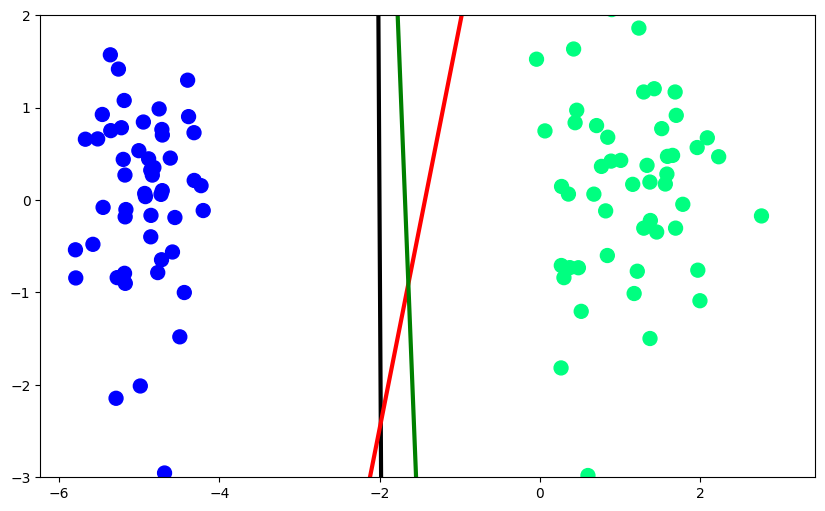

In [26]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='black', linewidth=3)
plt.plot(x_input, y_input1, color='red', linewidth=3)
plt.plot(x_input, y_input2, color='green', linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

## 🔁 Section 6: Logistic Regression using Gradient Descent

#### Implementing logistic regression using sigmoid activation and training it with gradient descent.

In [27]:
def perceptron_gradient_descent(X,y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.7

    for i in range(70000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + (lr * np.dot((y-y_hat) ,X)) / X.shape[0]
    return weights[0], weights[1:]

In [28]:
intercept_ , coef_ = perceptron_gradient_descent(X,y)

In [29]:
m3 = -(coef_[0]/coef_[1])
b3 = -(intercept_/coef_[1])

In [30]:
y_input3 = m3 * x_input + b3

(-3.0, 2.0)

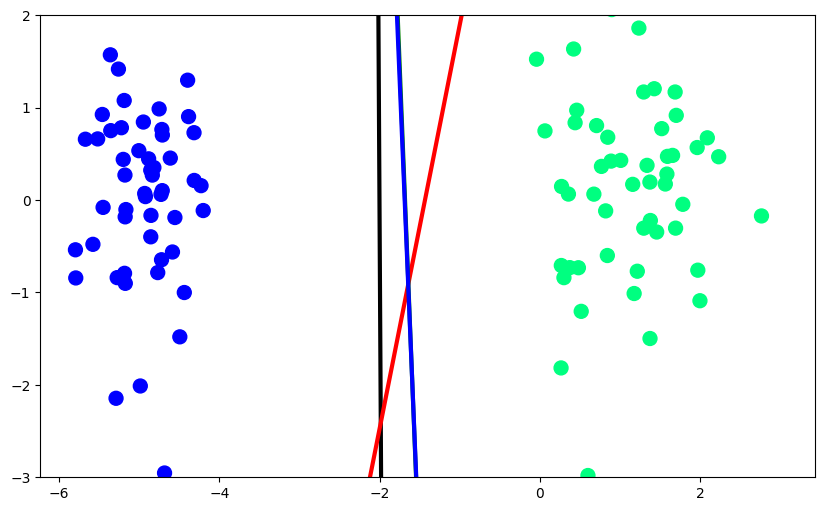

In [31]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='black', linewidth=3)
plt.plot(x_input, y_input1, color='red', linewidth=3)
plt.plot(x_input, y_input2, color='green', linewidth=3)
plt.plot(x_input, y_input3, color='blue', linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

## Summary

- ### Compared sklearn's implementation with custom implementations.
- ### Demonstrated training with gradient descent.
- ### Step function gave least reliable separation line.
- ### Sigmoid function gave similar line with both gradient descent and perceptron trick.